In [13]:
import pandas as pd

# Load dataset
df = pd.read_csv("tox21_compoundData.csv")

# Keep only ID, sdftitle + toxicity assay columns
cols_to_keep = ["ID", "sdftitle"] + list(df.columns[6:])  # assays start at col index 6
df = df[cols_to_keep]

# Inspect structure
print("=== Dataset Info ===")
print(df.info())

print("\n=== First 5 Rows ===")
print(df.head())

# Check missing values
print("\n=== Missing Values per Column ===")
print(df.isna().sum())

# Remove rows with missing values
df_clean = df.dropna()

print("\n=== Cleaned Data (First 5 Rows) ===")
print(df_clean.head())

print("\nOriginal shape:", df.shape)
print("After dropping missing values:", df_clean.shape)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12707 entries, 0 to 12706
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             12707 non-null  object 
 1   sdftitle       12707 non-null  object 
 2   NR.AhR         9051 non-null   float64
 3   NR.AR          10240 non-null  float64
 4   NR.AR.LBD      9434 non-null   float64
 5   NR.Aromatase   7968 non-null   float64
 6   NR.ER          8478 non-null   float64
 7   NR.ER.LBD      9640 non-null   float64
 8   NR.PPAR.gamma  9056 non-null   float64
 9   SR.ARE         7956 non-null   float64
 10  SR.ATAD5       9985 non-null   float64
 11  SR.HSE         9027 non-null   float64
 12  SR.MMP         8101 non-null   float64
 13  SR.p53         9519 non-null   float64
dtypes: float64(12), object(2)
memory usage: 1.4+ MB
None

=== First 5 Rows ===
                ID         sdftitle  NR.AhR  NR.AR  NR.AR.LBD  NR.Aromatase  \
0  NCGC

In [15]:
# Summarize key features using descriptive statistics
print("\n=== Descriptive Statistics (Toxicity Assay Results) ===")
print(df_clean.describe())


=== Descriptive Statistics (Toxicity Assay Results) ===
            NR.AhR        NR.AR    NR.AR.LBD  NR.Aromatase        NR.ER  \
count  2950.000000  2950.000000  2950.000000   2950.000000  2950.000000   
mean      0.037288     0.004068     0.002373      0.009831     0.038644   
std       0.189499     0.063660     0.048663      0.098677     0.192778   
min       0.000000     0.000000     0.000000      0.000000     0.000000   
25%       0.000000     0.000000     0.000000      0.000000     0.000000   
50%       0.000000     0.000000     0.000000      0.000000     0.000000   
75%       0.000000     0.000000     0.000000      0.000000     0.000000   
max       1.000000     1.000000     1.000000      1.000000     1.000000   

         NR.ER.LBD  NR.PPAR.gamma       SR.ARE     SR.ATAD5       SR.HSE  \
count  2950.000000    2950.000000  2950.000000  2950.000000  2950.000000   
mean      0.007458       0.006780     0.046102     0.003051     0.010508   
std       0.086050       0.082073     0

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only toxicity assay result columns
assay_cols = df_clean.columns[2:]  # from NR.AhR onwards

# Correlation matrix
corr = df_clean[assay_cols].corr()

print("=== Correlation Matrix ===")
print(corr)

=== Correlation Matrix ===
                 NR.AhR     NR.AR  NR.AR.LBD  NR.Aromatase     NR.ER  \
NR.AhR         1.000000  0.015532  -0.009598      0.071062  0.016236   
NR.AR          0.015532  1.000000   0.544191      0.047613  0.152974   
NR.AR.LBD     -0.009598  0.544191   1.000000      0.065758  0.134810   
NR.Aromatase   0.071062  0.047613   0.065758      1.000000  0.015675   
NR.ER          0.016236  0.152974   0.134810      0.015675  1.000000   
NR.ER.LBD      0.003736  0.365876   0.319695      0.031299  0.432341   
NR.PPAR.gamma  0.005543 -0.005280  -0.004029     -0.008232 -0.016565   
SR.ARE         0.212685  0.087536   0.088949      0.076400  0.048176   
SR.ATAD5       0.053995 -0.003535   0.123633     -0.005512 -0.011091   
SR.HSE         0.049901 -0.006586  -0.005026      0.057121 -0.003414   
SR.MMP         0.182907  0.021333  -0.008298      0.024603  0.093514   
SR.p53         0.030827 -0.002885  -0.002202     -0.004498  0.029985   

               NR.ER.LBD  NR.PPAR.ga

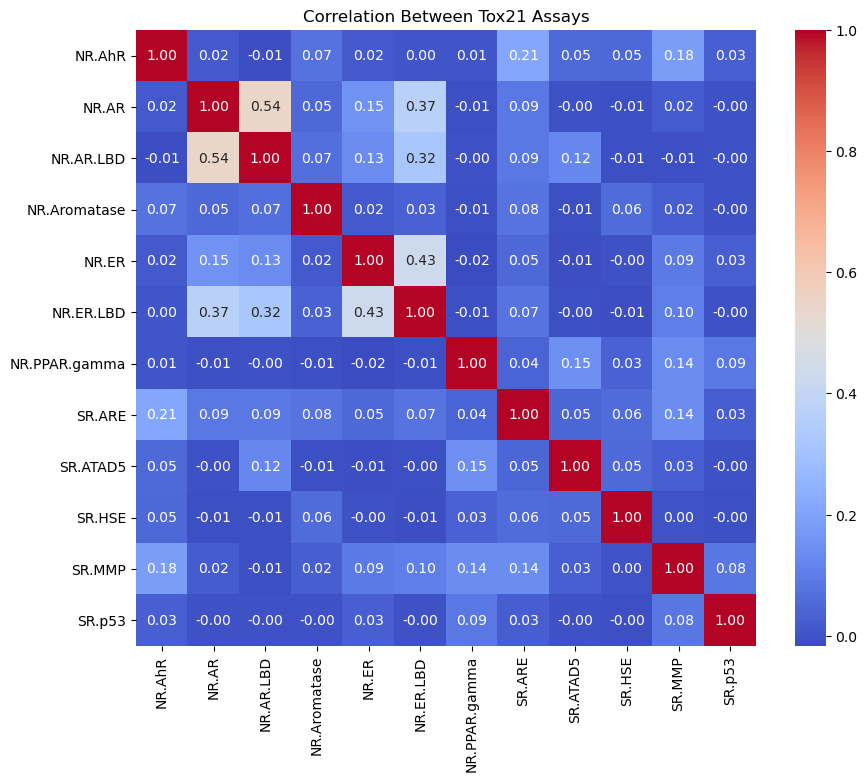

In [17]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", cbar=True)
plt.title("Correlation Between Tox21 Assays")
plt.show()

In [20]:
# Make a safe copy before adding new column
df_clean = df_clean.copy()

# Count number of assays positive per compound
df_clean["tox_count"] = df_clean[assay_cols].sum(axis=1)

# Summarize
print(df_clean["tox_count"].describe())

# Show most toxic compounds
print("\nMost toxic compounds:\n",
      df_clean.sort_values("tox_count", ascending=False).head())

count    2950.000000
mean        0.196271
std         0.554692
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         5.000000
Name: tox_count, dtype: float64

Most toxic compounds:
                    ID         sdftitle  NR.AhR  NR.AR  NR.AR.LBD  \
7295  NCGC00258093-01  NCGC00258093-01     0.0    1.0        1.0   
7472  NCGC00258764-01  NCGC00258764-01     0.0    1.0        1.0   
9197  NCGC00258243-01  NCGC00258243-01     0.0    1.0        1.0   
9399  NCGC00255321-01  NCGC00255321-01     0.0    1.0        1.0   
9203  NCGC00257077-01  NCGC00257077-01     1.0    0.0        0.0   

      NR.Aromatase  NR.ER  NR.ER.LBD  NR.PPAR.gamma  SR.ARE  SR.ATAD5  SR.HSE  \
7295           0.0    1.0        1.0            0.0     1.0       0.0     0.0   
7472           0.0    1.0        1.0            0.0     1.0       0.0     0.0   
9197           0.0    1.0        1.0            0.0     1.0       0.0     0.0   
9399           1.0    1.0        1.0       

In [21]:
# Select low-toxicity compounds
low_tox = df_clean[df_clean["tox_count"] == 0]

print("Number of low-toxicity compounds:", low_tox.shape[0])
print("\nExample low-toxicity compounds:\n", low_tox.head())

Number of low-toxicity compounds: 2520

Example low-toxicity compounds:
                    ID         sdftitle  NR.AhR  NR.AR  NR.AR.LBD  \
7798  NCGC00254768-01  NCGC00254768-01     0.0    0.0        0.0   
7872  NCGC00256389-01  NCGC00256389-01     0.0    0.0        0.0   
8252  NCGC00260253-01  NCGC00260253-01     0.0    0.0        0.0   
8254  NCGC00260212-01  NCGC00260212-01     0.0    0.0        0.0   
8265  NCGC00182994-01  NCGC00182994-01     0.0    0.0        0.0   

      NR.Aromatase  NR.ER  NR.ER.LBD  NR.PPAR.gamma  SR.ARE  SR.ATAD5  SR.HSE  \
7798           0.0    0.0        0.0            0.0     0.0       0.0     0.0   
7872           0.0    0.0        0.0            0.0     0.0       0.0     0.0   
8252           0.0    0.0        0.0            0.0     0.0       0.0     0.0   
8254           0.0    0.0        0.0            0.0     0.0       0.0     0.0   
8265           0.0    0.0        0.0            0.0     0.0       0.0     0.0   

      SR.MMP  SR.p53  tox_count

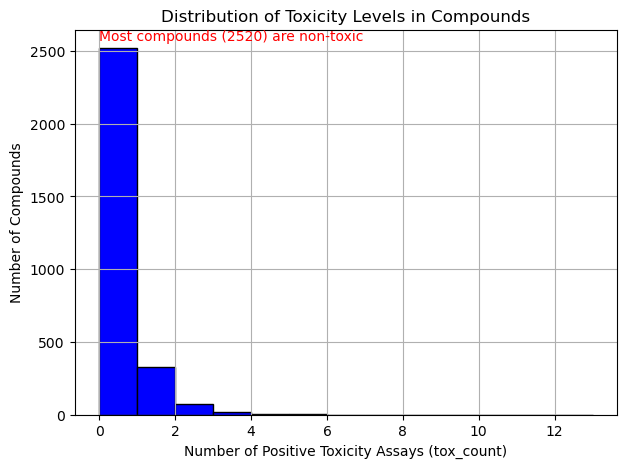

In [29]:
plt.figure(figsize=(7,5))
ax = df_clean["tox_count"].hist(bins=range(0, 14), edgecolor="black", color="blue")
plt.title("Distribution of Toxicity Levels in Compounds")
plt.xlabel("Number of Positive Toxicity Assays (tox_count)")
plt.ylabel("Number of Compounds")

# Annotate most common category (0 assays = non-toxic)
count_0 = (df_clean["tox_count"] == 0).sum()
plt.text(0, count_0+50, f"Most compounds ({count_0}) are non-toxic", color="red")

plt.show()

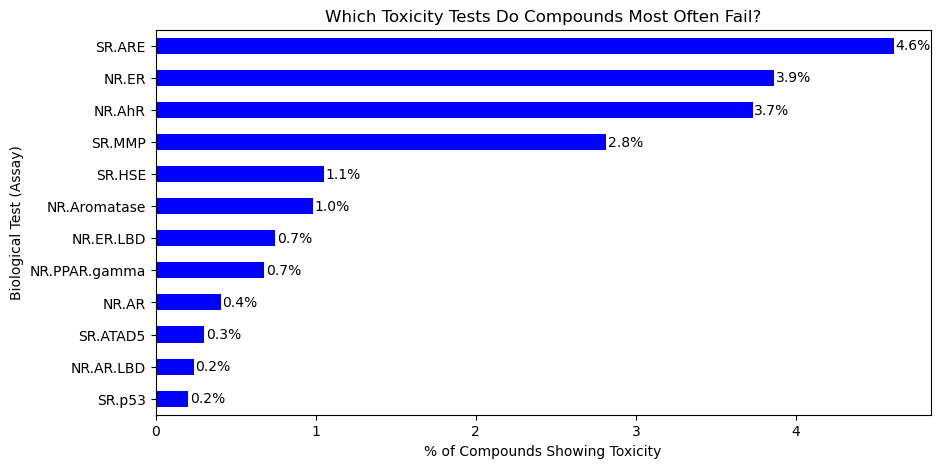

In [37]:
assay_means_percent = (df_clean[assay_cols].mean() * 100).sort_values()

plt.figure(figsize=(10,5))
ax = assay_means_percent.plot(kind="barh", color="blue")

plt.title("Which Toxicity Tests Do Compounds Most Often Fail?")
plt.xlabel("% of Compounds Showing Toxicity")
plt.ylabel("Biological Test (Assay)")

# Annotate values
for i, v in enumerate(assay_means_percent):
    plt.text(v + 0.01, i, f"{v:.1f}%", va="center")

plt.show()

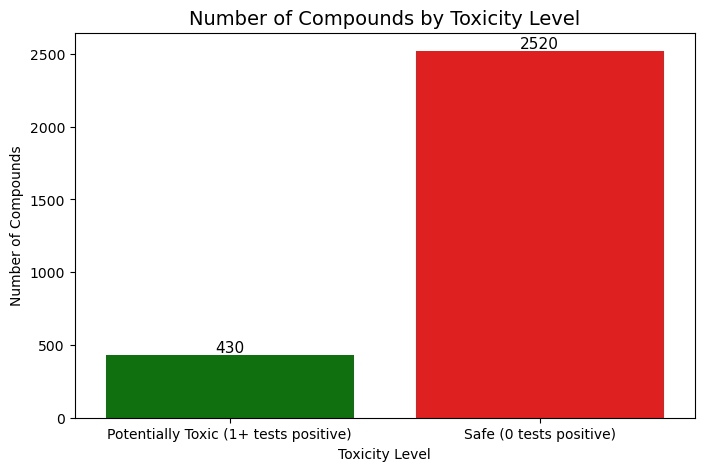

In [42]:
# Rename toxicity groups for clarity
df_clean["toxicity_group_friendly"] = df_clean["tox_count"].apply(
    lambda x: "Safe (0 tests positive)" if x == 0 else "Potentially Toxic (1+ tests positive)"
)

plt.figure(figsize=(8,5))
ax = sns.countplot(
    x="toxicity_group_friendly",
    data=df_clean,
    palette=["green", "red"]
)

plt.title("Number of Compounds by Toxicity Level", fontsize=14)
plt.xlabel("Toxicity Level")
plt.ylabel("Number of Compounds")

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha="center", va="bottom", fontsize=11)

plt.show()

**Summary of Findings**

Based on the Tox21 dataset analysis, we can highlight the following key insights:

1. **Most compounds are relatively safe  
   - Over half of the compounds show no activity in any assay.  
   - Around 70% of the dataset is in the "Safe (0 tests positive)" category, while fewer compounds fall into the "Potentially Toxic (1+ tests positive)" group.  
   - This suggests that the majority of tested compounds do not trigger strong toxicity signals across the assays.

2. **Some toxicity tests are more sensitive than others  
   - The **SR.ARE assay** flagged the highest proportion of compounds as toxic (4.6%).  
   - In contrast, other assays like **NR.AR.LBD** and **SR.p53** identified very few positives.  
   - This indicates that toxicity is not evenly distributed across tests, and certain pathways are more frequently affected.

3. **Relationships exist between toxicity assays 
   - Correlation analysis revealed that some assays tend to light up together (e.g., **NR.ER and NR.ER.LBD**).  
   - This reflects biological relationships, since assays targeting related receptors or pathways often show overlapping toxicity signals.  
   - Such patterns could help researchers prioritize which assays to monitor when screening new compounds.

**Overall:** The dataset shows that most compounds are safe, but a small subset consistently activates multiple assays. These may represent higher-risk drug candidates and warrant closer investigation.